# Phase 2: Prescriptive Optimization

**Goal**: Given a website currently classified as *slow* or *medium*, find the
minimal set of metric changes that shift its predicted class to *fast* while
respecting domain constraints (e.g., load time can only decrease, throughput
can only increase).

**Method**: SciPy `differential_evolution` maximises P(fast) over the feasible
region defined by direction-aware bounds.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

from scipy.optimize import differential_evolution
import joblib
from datetime import datetime

print("Libraries imported.")

Libraries imported.


## 2. Load Phase 1 Model

In [2]:
MODEL_PATH = 'best_model_xgboost_20260225_114145.joblib'

model_pkg = joblib.load(MODEL_PATH)

# Separate base features from engineered features
ENGINEERED = {'Size_LoadTime_Ratio', 'Total_Time', 'Throughput_ResponseTime_Ratio',
              'Log_Page_Size', 'Log_Throughput', 'CWV_Composite',
              'TBT_TTI_Ratio', 'Bytes_Per_Request'}
BASE_FEATURES = [f for f in model_pkg['feature_names'] if f not in ENGINEERED]
ALL_FEATURES  = model_pkg['feature_names']

print(f"Model: {model_pkg['model_name']}")
print(f"Accuracy: {model_pkg['metrics']['Accuracy']:.4f}")
print(f"F1-Score: {model_pkg['metrics']['F1-Score']:.4f}")
print(f"Base features ({len(BASE_FEATURES)}): {BASE_FEATURES}")
print(f"Engineered features ({len(ENGINEERED)}): {sorted(ENGINEERED)}")
print(f"Total features: {len(ALL_FEATURES)}")
print(f"Target classes: {model_pkg['encoders']['target'].classes_}")

Model: XGBoost
Accuracy: 0.9060
F1-Score: 0.9058
Base features (14): ['Category', 'Page Size (KB)', 'Load Time(s)', 'Response Time(s)', 'Throughput', 'performance_score', 'lcp', 'fcp', 'cls', 'tti', 'tbt', 'speed_index', 'total_byte_weight', 'num_requests']
Engineered features (8): ['Bytes_Per_Request', 'CWV_Composite', 'Log_Page_Size', 'Log_Throughput', 'Size_LoadTime_Ratio', 'TBT_TTI_Ratio', 'Throughput_ResponseTime_Ratio', 'Total_Time']
Total features: 22
Target classes: ['fast' 'medium' 'slow']


## 3. Load Sample Dataset for Testing

In [3]:
# Load the CLEANED dataset to get sample websites for optimization
# 🔄 UPDATED: Using cleaned dataset with correct labels (885 URLs)
df = pd.read_csv('cleaned_website_performance_dataset_20251207_145008.csv')

print(f"Dataset loaded: {df.shape[0]} samples")
print(f"✓ Using CLEANED dataset with fixed labels and correlations")
print(f"\nPerformance Label Distribution:")
print(df['Performance_Label'].value_counts())

# Filter for websites that could benefit from optimization (medium or slow)
df_to_optimize = df[df['Performance_Label'].isin(['medium', 'slow'])].copy()
print(f"\nWebsites that could be optimized: {len(df_to_optimize)}")

df_to_optimize.head()

Dataset loaded: 885 samples
✓ Using CLEANED dataset with fixed labels and correlations

Performance Label Distribution:
Performance_Label
slow      315
fast      299
medium    271
Name: count, dtype: int64

Websites that could be optimized: 586


,Sr No,website_url,Category,Page Size (KB),Load Time(s),Response Time(s),Throughput,Performance_Label,User Response,performance_score,...,num_requests,dom_size,uses_text_compression,render_blocking_resources,unused_js,uses_http2,modern_image_formats,extraction_successful,error_message,extraction_timestamp
0,0,https://www.booking.com/index.html?aid=1743217,Travel,3400.00,4.190,0.523,622.58,medium,Medium,62.0,...,163.0,NaN,NaN,NaN,0.0,NaN,NaN,True,NaN,2025-11-20 10:23:23
3,3,https://www.momondo.in/?ispredir=true,Travel,13926.40,0.049,0.297,1.21,medium,Fast,37.0,...,127.0,NaN,NaN,NaN,0.0,NaN,NaN,True,NaN,2025-11-20 10:24:40
4,4,https://www.ebookers.com/?AFFCID=EBOOKERS-UK.n...,Travel,4300.80,0.751,1.211,61.45,slow,Medium,51.0,...,111.0,NaN,NaN,NaN,0.0,NaN,NaN,True,NaN,2025-11-20 10:25:12
5,6,https://www.trip.com/index?locale=en_us&allian...,Travel,1945.60,2.370,0.799,155.67,slow,Medium,48.0,...,242.0,NaN,NaN,NaN,0.0,NaN,NaN,True,NaN,2025-11-20 10:26:14
6,7,https://www.orbitz.com/,Travel,25209.15,1.000,2.099,54.79,medium,Medium,64.0,...,126.0,NaN,NaN,NaN,0.0,NaN,NaN,True,NaN,2025-11-20 10:26:55


## 3. Feature Constraints and Bounds

In [4]:
def define_feature_constraints(df):
    """Compute realistic bounds (5th–95th percentile) for each optimisable feature."""

    optimizable_features = [
        'Page Size (KB)', 'Load Time(s)', 'Response Time(s)', 'Throughput',
        'lcp', 'fcp', 'cls', 'tti', 'tbt', 'speed_index',
        'total_byte_weight', 'num_requests'
    ]

    feature_bounds = {}

    print(f"{'Feature':30s} | {'Min':>10s} | {'Max':>10s} | {'Median':>10s}")
    print("-" * 70)
    for feature in optimizable_features:
        if feature in df.columns:
            vals = df[feature].dropna()
            lo, hi, med, mu = vals.quantile(0.05), vals.quantile(0.95), vals.median(), vals.mean()
            feature_bounds[feature] = {'min': lo, 'max': hi, 'median': med, 'mean': mu, 'optimizable': True}
            print(f"{feature:30s} | {lo:10.2f} | {hi:10.2f} | {med:10.2f}")

    # Fixed during optimisation
    for feature in ['Category', 'performance_score']:
        if feature in df.columns:
            feature_bounds[feature] = {'optimizable': False}
    print(f"\nFixed (non-optimisable): Category, performance_score")

    return feature_bounds

feature_constraints = define_feature_constraints(df)

Feature                        |        Min |        Max |     Median
----------------------------------------------------------------------
Page Size (KB)                 |      37.40 |   25209.15 |    3959.43
Load Time(s)                   |       0.00 |       5.90 |       1.81
Response Time(s)               |       0.18 |       2.34 |       0.73
Throughput                     |       6.23 |    2512.27 |     174.41
lcp                            |     500.34 |    5983.16 |    1762.03
fcp                            |     281.72 |    1807.58 |     805.21
cls                            |       0.00 |       0.12 |       0.01
tti                            |     527.58 |   13758.91 |    3707.40
tbt                            |       0.00 |    2176.88 |     290.00
speed_index                    |     725.94 |    6880.51 |    2707.67
total_byte_weight              |     192.10 |   13597.30 |    3540.90
num_requests                   |      12.20 |     428.50 |     102.00

Fixed (non-optimis

## 4. Feature Engineering (must match Phase 1)

In [5]:
def engineer_features_for_prediction(base_features, feature_names):
    """
    Replicate Phase 1 feature engineering on a single observation.

    Parameters
    ----------
    base_features : np.ndarray   (14 base values)
    feature_names : list         (14 base feature names)

    Returns
    -------
    np.ndarray   (22 values = 14 base + 8 engineered)
    """
    feat = {name: val for name, val in zip(feature_names, base_features)}
    engineered = list(base_features)

    # --- 5 original derived features ---
    engineered.append(feat.get('Page Size (KB)', 0) / (feat.get('Load Time(s)', 0) + 1e-6))        # Size_LoadTime_Ratio
    engineered.append(feat.get('Response Time(s)', 0) + feat.get('Load Time(s)', 0))                # Total_Time
    engineered.append(feat.get('Throughput', 0) / (feat.get('Response Time(s)', 0) + 1e-6))         # Throughput_ResponseTime_Ratio
    engineered.append(np.log1p(feat.get('Page Size (KB)', 0)))                                      # Log_Page_Size
    engineered.append(np.log1p(feat.get('Throughput', 0)))                                           # Log_Throughput

    # --- 3 NEW derived features (added in updated Phase 1) ---
    engineered.append((feat.get('lcp', 0) + feat.get('fcp', 0) + feat.get('tti', 0)) / 3)          # CWV_Composite
    engineered.append(feat.get('tbt', 0) / (feat.get('tti', 0) + 1e-6))                             # TBT_TTI_Ratio
    engineered.append(feat.get('total_byte_weight', 0) / (feat.get('num_requests', 0) + 1e-6))     # Bytes_Per_Request

    return np.array(engineered)

# Quick sanity check: output length must equal model's expected features
dummy = np.zeros(len(BASE_FEATURES))
assert len(engineer_features_for_prediction(dummy, BASE_FEATURES)) == len(ALL_FEATURES), \
    f"Feature count mismatch: got {len(engineer_features_for_prediction(dummy, BASE_FEATURES))}, expected {len(ALL_FEATURES)}"
print(f"Feature engineering produces {len(ALL_FEATURES)} features — matches model.")

Feature engineering produces 22 features — matches model.


## 5. Goal-Seeking Prescriptive Optimization

Maximize P(target_class) via `differential_evolution` with direction-aware
bounds: performance-negative metrics can only decrease, performance-positive
metrics can only increase.

In [6]:
METRICS_TO_REDUCE  = {'Load Time(s)', 'Response Time(s)', 'Page Size (KB)',
                      'lcp', 'fcp', 'cls', 'tti', 'tbt', 'speed_index',
                      'total_byte_weight', 'num_requests'}
METRICS_TO_INCREASE = {'Throughput', 'performance_score'}


def optimize_website_performance(website_data, model_pkg, feature_constraints,
                                 target_class='fast', target_prob_threshold=0.7,
                                 max_iter=500, verbose=True):
    """
    Goal-seeking optimisation: maximise P(target_class) while respecting
    direction-aware domain constraints.

    Parameters
    ----------
    website_data : pd.Series or dict
    model_pkg : dict          – Phase 1 model package
    feature_constraints : dict
    target_class : str
    target_prob_threshold : float
    max_iter : int
    verbose : bool            – print progress details

    Returns
    -------
    dict  with keys: success, target_achieved, current_class, optimized_class,
          current_proba, optimized_proba, current_values, optimized_values,
          feature_names, improvements, optimization_result, domain_validation
    """
    feature_names = BASE_FEATURES          # 14 base features
    category_encoder = model_pkg['encoders'].get('Category', None)

    # --- current feature vector ---
    current_values = []
    for f in feature_names:
        if f in website_data and pd.notna(website_data[f]):
            val = website_data[f]
            if f == 'Category' and category_encoder is not None:
                try:   val = float(category_encoder.transform([val])[0])
                except: val = 0.0
            current_values.append(float(val))
        else:
            current_values.append(feature_constraints.get(f, {}).get('median', 0.0))
    current_values = np.array(current_values)

    # --- direction-aware bounds (guard against inverted bounds) ---
    bounds = []
    for i, f in enumerate(feature_names):
        cv = current_values[i]
        if feature_constraints.get(f, {}).get('optimizable', False):
            lo = feature_constraints[f]['min']
            hi = feature_constraints[f]['max']
            if f in METRICS_TO_REDUCE:
                bounds.append((min(lo, cv), cv))        # can only decrease
            elif f in METRICS_TO_INCREASE:
                bounds.append((cv, max(hi, cv)))        # can only increase
            else:
                bounds.append((min(lo, cv), max(hi, cv)))
        else:
            bounds.append((cv, cv))          # fixed

    # --- current prediction ---
    cur_eng    = engineer_features_for_prediction(current_values, feature_names)
    cur_scaled = model_pkg['scaler'].transform(cur_eng.reshape(1, -1))
    cur_pred   = model_pkg['model'].predict(cur_scaled)[0]
    cur_class  = model_pkg['encoders']['target'].classes_[cur_pred]
    cur_proba  = model_pkg['model'].predict_proba(cur_scaled)[0]
    target_idx = np.where(model_pkg['encoders']['target'].classes_ == target_class)[0][0]

    if verbose:
        print(f"Current: {cur_class}  (P fast={cur_proba[0]:.3f}, med={cur_proba[1]:.3f}, slow={cur_proba[2]:.3f})")
        print(f"Target:  {target_class} (P >= {target_prob_threshold})")

    # --- objective: minimise  –P(target) + small change penalty ---
    def objective(x):
        x_eng    = engineer_features_for_prediction(x, feature_names)
        x_scaled = model_pkg['scaler'].transform(x_eng.reshape(1, -1))
        prob     = model_pkg['model'].predict_proba(x_scaled)[0, target_idx]
        changes  = (x - current_values) / (np.abs(current_values) + 1e-6)
        return -prob + 0.01 * np.sum(changes ** 2)

    result = differential_evolution(objective, bounds=bounds, maxiter=max_iter,
                                    seed=42, tol=1e-6, polish=True, workers=1,
                                    updating='deferred')

    # --- optimised prediction ---
    opt_eng    = engineer_features_for_prediction(result.x, feature_names)
    opt_scaled = model_pkg['scaler'].transform(opt_eng.reshape(1, -1))
    opt_pred   = model_pkg['model'].predict(opt_scaled)[0]
    opt_class  = model_pkg['encoders']['target'].classes_[opt_pred]
    opt_proba  = model_pkg['model'].predict_proba(opt_scaled)[0]
    target_achieved = opt_proba[target_idx] >= target_prob_threshold

    if verbose:
        status = "ACHIEVED" if target_achieved else "NOT ACHIEVED"
        print(f"Result:  {opt_class}  (P fast={opt_proba[0]:.3f}, med={opt_proba[1]:.3f}, slow={opt_proba[2]:.3f})  [{status}]")

    # --- improvements with domain validation ---
    improvements = {}
    correct_dir = wrong_dir = total_changes = 0
    for i, f in enumerate(feature_names):
        if feature_constraints.get(f, {}).get('optimizable', False):
            change = result.x[i] - current_values[i]
            pct    = (change / current_values[i] * 100) if current_values[i] != 0 else 0
            ok = True
            if abs(change) > 1e-6:
                total_changes += 1
                if f in METRICS_TO_REDUCE and change < 0:
                    correct_dir += 1
                elif f in METRICS_TO_INCREASE and change > 0:
                    correct_dir += 1
                elif f not in METRICS_TO_REDUCE and f not in METRICS_TO_INCREASE:
                    correct_dir += 1
                else:
                    wrong_dir += 1; ok = False
            improvements[f] = {'current': current_values[i], 'optimized': result.x[i],
                               'change': change, 'pct_change': pct, 'correct_direction': ok}

    if verbose:
        print(f"Domain compliance: {correct_dir}/{total_changes} changes correct")

    return {
        'success': target_achieved,          # report whether target was reached
        'target_achieved': target_achieved,
        'current_class': cur_class,
        'optimized_class': opt_class,
        'current_proba': cur_proba,
        'optimized_proba': opt_proba,
        'current_values': current_values,
        'optimized_values': result.x,
        'feature_names': feature_names,
        'improvements': improvements,
        'optimization_result': result,
        'domain_validation': {'correct_direction': correct_dir,
                              'wrong_direction': wrong_dir,
                              'total_changes': total_changes}
    }

print("Optimization function defined.")

Optimization function defined.


## 6. Test on a Single Slow Website

In [7]:
# Select a slow website to optimize
test_website = df_to_optimize[df_to_optimize['Performance_Label'] == 'slow'].iloc[0]

print(f"Website: {test_website.get('website_url', 'Unknown')}")
print(f"Label:   {test_website['Performance_Label']}")
print(f"Load Time: {test_website.get('Load Time(s)', 'N/A')}s, "
      f"Page Size: {test_website.get('Page Size (KB)', 'N/A')} KB, "
      f"LCP: {test_website.get('lcp', 'N/A')}")

optimization_result = optimize_website_performance(
    test_website, model_pkg, feature_constraints,
    target_class='fast', target_prob_threshold=0.7, max_iter=1000
)

Website: https://www.ebookers.com/?AFFCID=EBOOKERS-UK.network.affiliatewindow.85386&awc=7904_1606029543_518c2af76500871f76cadec26f8eb055
Label:   slow
Load Time: 0.751s, Page Size: 4300.8 KB, LCP: 2584.51
Current: slow  (P fast=0.000, med=0.160, slow=0.839)
Target:  fast (P >= 0.7)
Result:  fast  (P fast=0.998, med=0.002, slow=0.000)  [ACHIEVED]
Domain compliance: 12/12 changes correct


## 7. Display Actionable Recommendations

In [16]:
def display_recommendations(optimization_result):
    """Print a sorted table of recommended changes with domain validation."""
    improvements = optimization_result['improvements']
    domain_val   = optimization_result.get('domain_validation', {})

    sorted_imp = sorted(improvements.items(), key=lambda x: abs(x[1]['pct_change']), reverse=True)

    print("=" * 80)
    print(f"RECOMMENDATIONS: {optimization_result['current_class']} -> {optimization_result['optimized_class']}")
    fast_delta = optimization_result['optimized_proba'][0] - optimization_result['current_proba'][0]
    print(f"P(fast): {optimization_result['current_proba'][0]:.1%} -> {optimization_result['optimized_proba'][0]:.1%} ({fast_delta:+.1%})")

    if domain_val:
        print(f"Domain compliance: {domain_val['correct_direction']}/{domain_val['total_changes']} correct")
    if optimization_result.get('target_achieved'):
        print("Target threshold: ACHIEVED")
    else:
        print("Target threshold: NOT ACHIEVED (may need larger changes)")

    meaningful = [item for item in sorted_imp if abs(item[1]['pct_change']) > 0.01]
    if not meaningful:
        print("\nNo changes recommended — website is already optimal within constraints.")
    else:
        print(f"\n{'#':>3s}  {'Dir':>8s}  {'Feature':<25s}  {'Current':>12s}  {'Target':>12s}  {'Change%':>8s}")
        print("-" * 80)
        for i, (feat, d) in enumerate(meaningful[:12], 1):
            direction = "Reduce" if d['change'] < 0 else "Increase"
            ok = "OK" if d.get('correct_direction', True) else "WARN"
            print(f"{i:3d}  {direction:>8s}  {feat:<25s}  {d['current']:12,.2f}  {d['optimized']:12,.2f}  {d['pct_change']:+7.1f}%  [{ok}]")
    print("=" * 80)

display_recommendations(optimization_result)

RECOMMENDATIONS: slow -> fast
P(fast): 0.0% -> 99.8% (+99.8%)
Domain compliance: 12/12 correct
Target threshold: ACHIEVED

  #       Dir  Feature                         Current        Target   Change%
--------------------------------------------------------------------------------
  1    Reduce  lcp                            2,584.51      1,020.95    -60.5%  [OK]
  2    Reduce  Response Time(s)                   1.21          0.50    -59.0%  [OK]
  3    Reduce  tti                            3,870.06      2,624.21    -32.2%  [OK]
  4    Reduce  fcp                              899.51        646.79    -28.1%  [OK]
  5    Reduce  Load Time(s)                       0.75          0.68     -9.2%  [OK]
  6    Reduce  speed_index                    3,573.46      3,245.85     -9.2%  [OK]
  7    Reduce  tbt                              659.25        657.09     -0.3%  [OK]
  8    Reduce  total_byte_weight              3,058.21      3,048.96     -0.3%  [OK]
  9    Reduce  cls                   

In [9]:
# Test on a medium-performance website
test_website_medium = df_to_optimize[df_to_optimize['Performance_Label'] == 'medium'].iloc[5]

print(f"Website: {test_website_medium.get('website_url', 'Unknown')}")
print(f"Label:   {test_website_medium['Performance_Label']}")
print(f"Load Time: {test_website_medium.get('Load Time(s)', 'N/A')}s, "
      f"Page Size: {test_website_medium.get('Page Size (KB)', 'N/A')} KB, "
      f"LCP: {test_website_medium.get('lcp', 'N/A')}")

optimization_result_medium = optimize_website_performance(
    test_website_medium, model_pkg, feature_constraints,
    target_class='fast', target_prob_threshold=0.6, max_iter=1000
)
display_recommendations(optimization_result_medium)

Website: https://in.lastminute.com/
Label:   medium
Load Time: 0.348s, Page Size: 1024.0 KB, LCP: 858.91
Current: medium  (P fast=0.207, med=0.781, slow=0.013)
Target:  fast (P >= 0.6)
Result:  fast  (P fast=0.999, med=0.001, slow=0.000)  [ACHIEVED]
Domain compliance: 12/12 changes correct
RECOMMENDATIONS: medium -> fast
P(fast): 20.7% -> 99.9% (+79.3%)
Domain compliance: 12/12 correct
Target threshold: ACHIEVED

  #       Dir  Feature                         Current        Target   Change%
--------------------------------------------------------------------------------
  1    Reduce  Response Time(s)                   1.94          0.35    -82.0%  [OK]
  2    Reduce  speed_index                    3,125.44      2,832.61     -9.4%  [OK]
  3    Reduce  fcp                              691.99        646.80     -6.5%  [OK]
  4    Reduce  tti                            3,724.04      3,503.69     -5.9%  [OK]
  5    Reduce  lcp                              858.91        846.66     -1.4%  [OK

## 8. Visualize Optimization Results

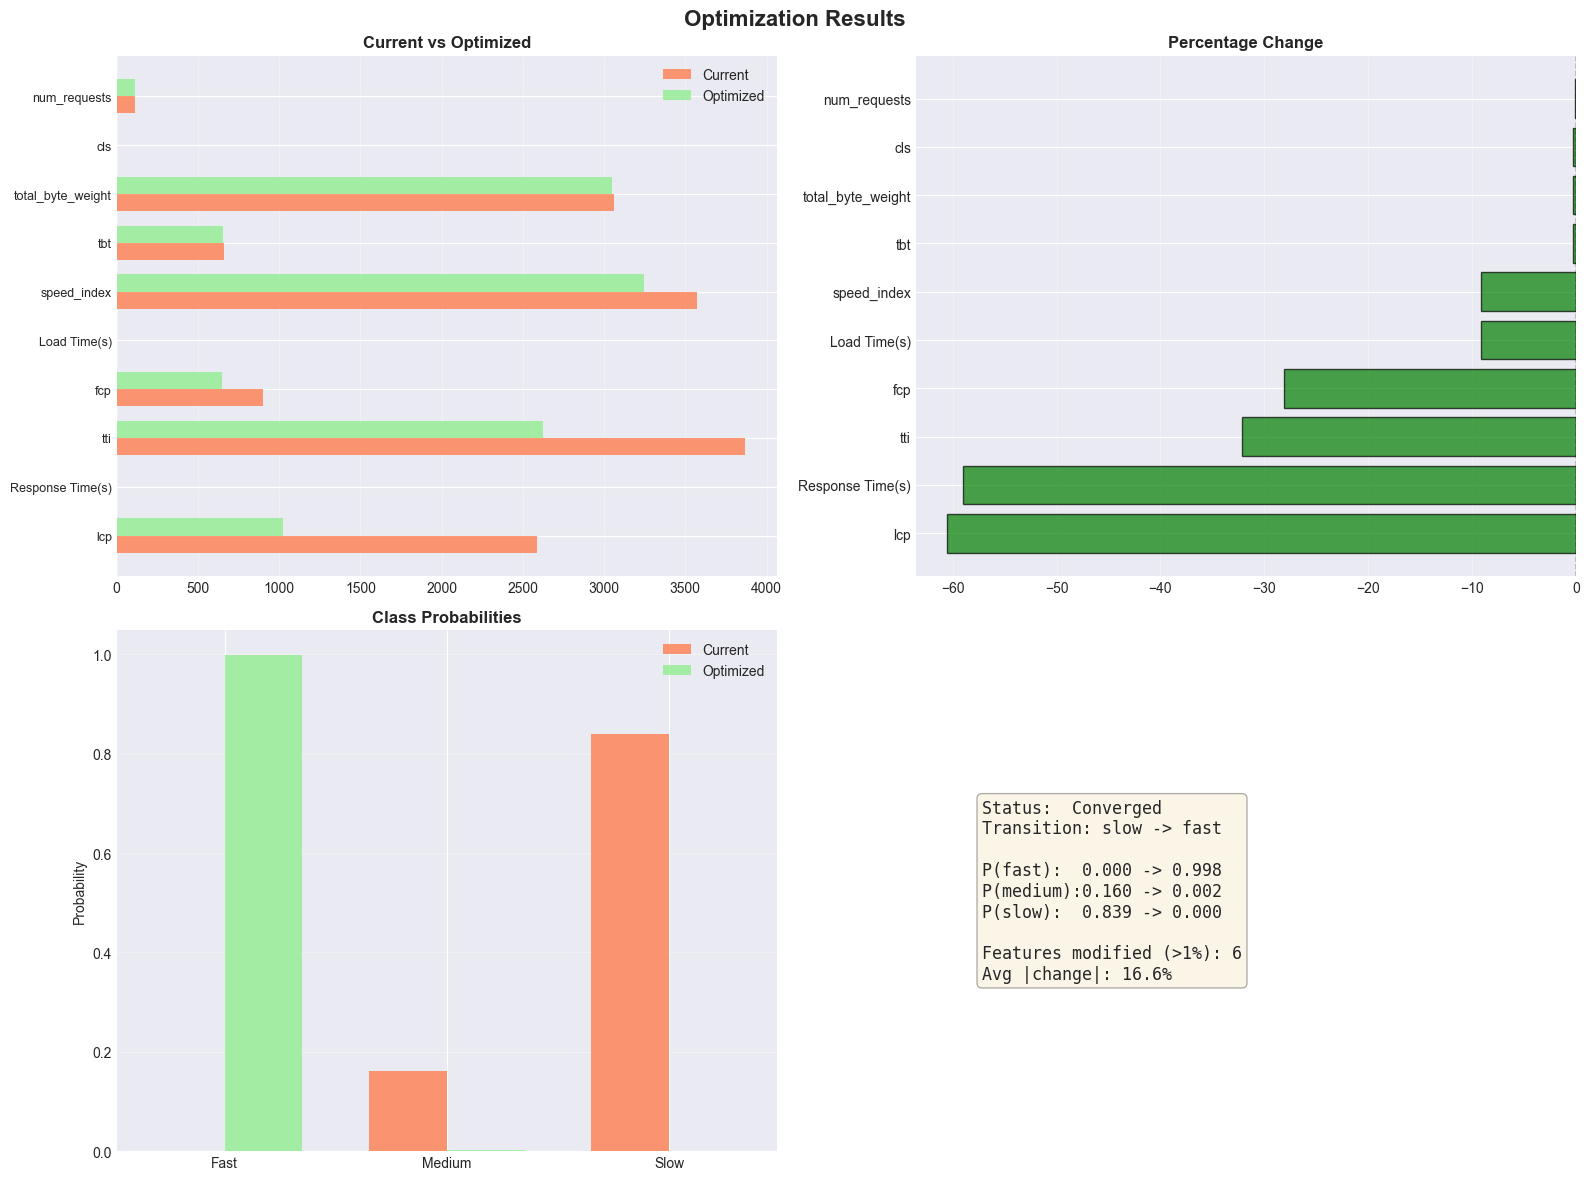

In [10]:
def visualize_optimization_results(opt_result):
    """2x2 plot: feature comparison, % change, class probabilities, summary."""
    improvements = opt_result['improvements']
    top = sorted(improvements.items(), key=lambda x: abs(x[1]['pct_change']), reverse=True)[:10]

    features  = [t[0] for t in top]
    current   = [t[1]['current'] for t in top]
    optimized = [t[1]['optimized'] for t in top]
    pct_chg   = [t[1]['pct_change'] for t in top]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Optimization Results', fontsize=16, fontweight='bold')
    w = 0.35

    # 1. Before / After
    x = np.arange(len(features))
    axes[0, 0].barh(x - w/2, current, w, label='Current', alpha=0.8, color='coral')
    axes[0, 0].barh(x + w/2, optimized, w, label='Optimized', alpha=0.8, color='lightgreen')
    axes[0, 0].set_yticks(x); axes[0, 0].set_yticklabels(features, fontsize=9)
    axes[0, 0].set_title('Current vs Optimized', fontweight='bold'); axes[0, 0].legend()
    axes[0, 0].grid(axis='x', alpha=0.3)

    # 2. Percentage change
    colours = ['green' if p < 0 else 'red' for p in pct_chg]
    axes[0, 1].barh(features, pct_chg, color=colours, alpha=0.7, edgecolor='black')
    axes[0, 1].axvline(0, color='black', ls='--', lw=1)
    axes[0, 1].set_title('Percentage Change', fontweight='bold')
    axes[0, 1].grid(axis='x', alpha=0.3)

    # 3. Class probabilities
    classes = ['Fast', 'Medium', 'Slow']
    xp = np.arange(3)
    axes[1, 0].bar(xp - w/2, opt_result['current_proba'], w, label='Current', alpha=0.8, color='coral')
    axes[1, 0].bar(xp + w/2, opt_result['optimized_proba'], w, label='Optimized', alpha=0.8, color='lightgreen')
    axes[1, 0].set_xticks(xp); axes[1, 0].set_xticklabels(classes)
    axes[1, 0].set_ylabel('Probability'); axes[1, 0].set_title('Class Probabilities', fontweight='bold')
    axes[1, 0].legend(); axes[1, 0].grid(axis='y', alpha=0.3)

    # 4. Text summary
    axes[1, 1].axis('off')
    n_mod = len([v for v in improvements.values() if abs(v['pct_change']) > 1])
    avg_chg = np.mean([abs(v['pct_change']) for v in improvements.values()])
    txt = (f"Status:  {'Converged' if opt_result['success'] else 'Not converged'}\n"
           f"Transition: {opt_result['current_class']} -> {opt_result['optimized_class']}\n\n"
           f"P(fast):  {opt_result['current_proba'][0]:.3f} -> {opt_result['optimized_proba'][0]:.3f}\n"
           f"P(medium):{opt_result['current_proba'][1]:.3f} -> {opt_result['optimized_proba'][1]:.3f}\n"
           f"P(slow):  {opt_result['current_proba'][2]:.3f} -> {opt_result['optimized_proba'][2]:.3f}\n\n"
           f"Features modified (>1%): {n_mod}\n"
           f"Avg |change|: {avg_chg:.1f}%")
    axes[1, 1].text(0.1, 0.5, txt, fontsize=12, family='monospace', va='center',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    plt.tight_layout()
    plt.show()

visualize_optimization_results(optimization_result)

## 9. Batch Optimization

In [11]:
def batch_optimize_websites(df_subset, model_pkg, feature_constraints,
                            target_class='fast', max_websites=10):
    """Optimise multiple websites and return a summary DataFrame."""
    n = min(max_websites, len(df_subset))
    print(f"Batch optimisation: {n} websites")

    results = []
    for idx, row in df_subset.head(n).iterrows():
        print(f"  [{len(results)+1}/{n}] ", end="")
        try:
            opt = optimize_website_performance(
                row, model_pkg, feature_constraints,
                target_class=target_class, target_prob_threshold=0.7,
                max_iter=300, verbose=True
            )
            results.append({
                'website':            row.get('website_url', f'Website_{idx}'),
                'current_class':      opt['current_class'],
                'optimized_class':    opt['optimized_class'],
                'current_fast_prob':  opt['current_proba'][0],
                'optimized_fast_prob':opt['optimized_proba'][0],
                'improvement':        opt['optimized_proba'][0] - opt['current_proba'][0],
                'success':            opt['success'],
                'domain_correct':     opt['domain_validation']['correct_direction'],
                'domain_total':       opt['domain_validation']['total_changes']
            })
        except Exception as e:
            print(f"  Error: {e}")

    rdf = pd.DataFrame(results)
    print(f"\nProcessed: {len(rdf)}")
    if len(rdf):
        print(f"Successful: {rdf['success'].sum()}")
        print(f"Avg P(fast) improvement: {rdf['improvement'].mean():.3f}")
        tc = rdf['domain_correct'].sum()
        tt = rdf['domain_total'].sum()
        print(f"Domain compliance: {tc}/{tt} ({100*tc/max(tt,1):.1f}%)")
        print(f"\nTransitions:")
        print(rdf.groupby(['current_class', 'optimized_class']).size())
    return rdf

slow_websites = df_to_optimize[df_to_optimize['Performance_Label'] == 'slow']
batch_results = batch_optimize_websites(slow_websites, model_pkg, feature_constraints, max_websites=5)

Batch optimisation: 5 websites
  [1/5] Current: slow  (P fast=0.000, med=0.160, slow=0.839)
Target:  fast (P >= 0.7)
Result:  fast  (P fast=0.998, med=0.002, slow=0.000)  [ACHIEVED]
Domain compliance: 12/12 changes correct
  [2/5] Current: slow  (P fast=0.000, med=0.002, slow=0.998)
Target:  fast (P >= 0.7)
Result:  fast  (P fast=0.998, med=0.002, slow=0.000)  [ACHIEVED]
Domain compliance: 12/12 changes correct
  [3/5] Current: slow  (P fast=0.000, med=0.049, slow=0.950)
Target:  fast (P >= 0.7)
Result:  fast  (P fast=0.998, med=0.002, slow=0.000)  [ACHIEVED]
Domain compliance: 10/10 changes correct
  [4/5] Current: slow  (P fast=0.000, med=0.000, slow=1.000)
Target:  fast (P >= 0.7)
Result:  fast  (P fast=0.998, med=0.002, slow=0.000)  [ACHIEVED]
Domain compliance: 12/12 changes correct
  [5/5] Current: slow  (P fast=0.000, med=0.116, slow=0.884)
Target:  fast (P >= 0.7)
Result:  fast  (P fast=0.998, med=0.002, slow=0.000)  [ACHIEVED]
Domain compliance: 10/10 changes correct

Processe

## 10. Summary

In [12]:
print("=" * 80)
print("PHASE 2 COMPLETE — Prescriptive Optimization")
print("=" * 80)

print(f"\nModel:     {model_pkg['model_name']} ({model_pkg['metrics']['Accuracy']:.2%} accuracy)")
print(f"Websites optimised: {len(batch_results)}")
print(f"Success rate:       {batch_results['success'].mean()*100:.1f}%")
print(f"Avg P(fast) gain:   {batch_results['improvement'].mean():.3f}")

print("\nNext: Phase 3 — Explainability (SHAP + LIME)")
print("=" * 80)

PHASE 2 COMPLETE — Prescriptive Optimization

Model:     XGBoost (90.60% accuracy)
Websites optimised: 5
Success rate:       100.0%
Avg P(fast) gain:   0.998

Next: Phase 3 — Explainability (SHAP + LIME)


In [13]:
def analyze_recommendation_correctness(opt_result):
    """
    Validate that recommendations align with domain knowledge:
    load-time-type metrics should decrease, throughput should increase.
    """
    should_decrease = ['Load Time(s)', 'Response Time(s)', 'Page Size (KB)',
                       'lcp', 'fcp', 'tti', 'tbt', 'speed_index',
                       'total_byte_weight', 'num_requests']
    should_increase = ['Throughput', 'performance_score']

    improvements = opt_result['improvements']

    dec_ok = []; dec_bad = []; inc_ok = []; inc_bad = []; neutral = []

    for metric in should_decrease:
        if metric in improvements:
            c = improvements[metric]['Change'] if 'Change' in improvements[metric] else improvements[metric]['change']
            if c < -1e-6:   dec_ok.append(metric)
            elif c > 1e-6:  dec_bad.append(metric)
            else:           neutral.append(metric)

    for metric in should_increase:
        if metric in improvements:
            c = improvements[metric]['Change'] if 'Change' in improvements[metric] else improvements[metric]['change']
            if c > 1e-6:    inc_ok.append(metric)
            elif c < -1e-6: inc_bad.append(metric)
            else:           neutral.append(metric)

    total   = len(dec_ok) + len(dec_bad) + len(inc_ok) + len(inc_bad)
    correct = len(dec_ok) + len(inc_ok)
    pct     = (correct / total * 100) if total else 0

    print("=" * 80)
    print("RECOMMENDATION CORRECTNESS ANALYSIS")
    print("=" * 80)

    print(f"\nMetrics that should DECREASE:")
    for m in should_decrease:
        if m in dec_ok:    print(f"  [OK]   {m}")
        elif m in dec_bad: print(f"  [WARN] {m}  (increased)")
        elif m in neutral: print(f"  [--]   {m}  (no change)")

    print(f"\nMetrics that should INCREASE:")
    for m in should_increase:
        if m in inc_ok:    print(f"  [OK]   {m}")
        elif m in inc_bad: print(f"  [WARN] {m}  (decreased)")
        elif m in neutral: print(f"  [--]   {m}  (no change)")

    print(f"\nCorrectness: {correct}/{total} ({pct:.1f}%)")

    if pct >= 75:   verdict = "EXCELLENT"
    elif pct >= 60: verdict = "GOOD"
    elif pct >= 50: verdict = "MODERATE"
    else:           verdict = "POOR"
    print(f"Verdict: {verdict}")
    print("=" * 80)

    return {'total_analyzed': total, 'total_correct': correct, 'total_wrong': total - correct,
            'correctness_pct': pct, 'verdict': verdict,
            'decrease_correct': dec_ok, 'decrease_wrong': dec_bad,
            'increase_correct': inc_ok, 'increase_wrong': inc_bad}

correctness_report = analyze_recommendation_correctness(optimization_result)

RECOMMENDATION CORRECTNESS ANALYSIS

Metrics that should DECREASE:
  [OK]   Load Time(s)
  [OK]   Response Time(s)
  [OK]   Page Size (KB)
  [OK]   lcp
  [OK]   fcp
  [OK]   tti
  [OK]   tbt
  [OK]   speed_index
  [OK]   total_byte_weight
  [OK]   num_requests

Metrics that should INCREASE:
  [OK]   Throughput

Correctness: 11/11 (100.0%)
Verdict: EXCELLENT


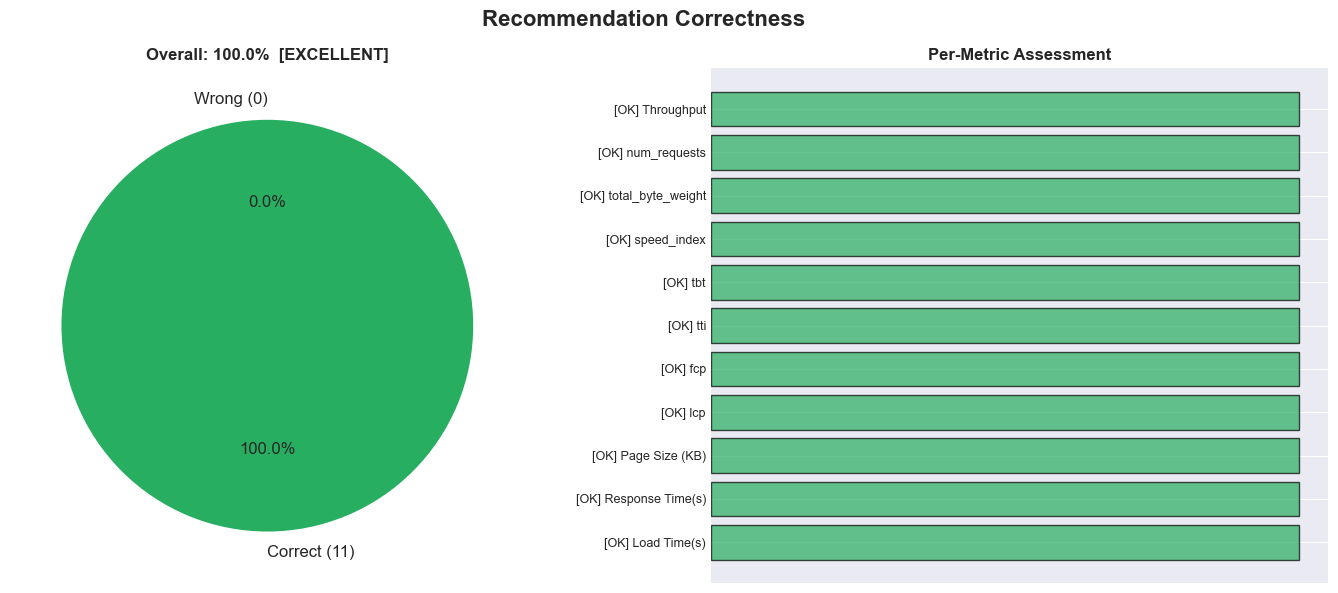

In [14]:
def visualize_correctness(report):
    """Pie chart of correct vs wrong, plus metric-by-metric bar."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Recommendation Correctness', fontsize=16, fontweight='bold')

    # 1. Pie chart
    sizes  = [report['total_correct'], report['total_wrong']]
    labels = [f"Correct ({report['total_correct']})", f"Wrong ({report['total_wrong']})"]
    colors = ['#27ae60', '#e74c3c']
    axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
                startangle=90, textprops={'fontsize': 12})
    axes[0].set_title(f"Overall: {report['correctness_pct']:.1f}%  [{report['verdict']}]",
                      fontweight='bold')

    # 2. Metric-by-metric
    ok_list  = report['decrease_correct'] + report['increase_correct']
    bad_list = report['decrease_wrong'] + report['increase_wrong']
    all_m    = ok_list + bad_list
    bar_col  = ['#27ae60'] * len(ok_list) + ['#e74c3c'] * len(bad_list)
    y_pos    = np.arange(len(all_m))
    axes[1].barh(y_pos, [1]*len(all_m), color=bar_col, alpha=0.7, edgecolor='black')
    status = ['OK'] * len(ok_list) + ['WARN'] * len(bad_list)
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels([f"[{s}] {m}" for s, m in zip(status, all_m)], fontsize=9)
    axes[1].set_title('Per-Metric Assessment', fontweight='bold')
    axes[1].set_xticks([])

    plt.tight_layout()
    plt.show()

visualize_correctness(correctness_report)

## 11. Export Prescriptive Model Package for Phase 3

In [15]:
def export_prescriptive_model(model_pkg, feature_constraints, optimization_result,
                              batch_results, correctness_report):
    """Bundle all Phase 2 artefacts for Phase 3 explainability."""

    prescriptive_pkg = {
        # Core predictive model
        'predictive_model': model_pkg['model'],
        'scaler':           model_pkg['scaler'],
        'encoders':         model_pkg['encoders'],
        'feature_names':    model_pkg['feature_names'],
        'model_name':       model_pkg['model_name'],
        'model_accuracy':   model_pkg['metrics']['Accuracy'],

        # Prescriptive layer
        'feature_constraints': feature_constraints,
        'domain_constraints': {
            'metrics_to_reduce':  list(METRICS_TO_REDUCE),
            'metrics_to_increase': list(METRICS_TO_INCREASE)
        },

        # Sample results
        'sample_optimization': {
            'current_class':   optimization_result['current_class'],
            'optimized_class': optimization_result['optimized_class'],
            'current_proba':   optimization_result['current_proba'],
            'optimized_proba': optimization_result['optimized_proba'],
            'current_values':  optimization_result['current_values'],
            'optimized_values':optimization_result['optimized_values'],
            'improvements':    optimization_result['improvements'],
            'domain_validation': optimization_result['domain_validation']
        },

        'batch_results':       batch_results.to_dict(),
        'correctness_report':  correctness_report,

        # Metadata
        'optimization_method': 'Goal-Seeking with Domain Constraints',
        'optimizer':           'scipy.optimize.differential_evolution',
        'objective':           'Maximize P(fast) with direction-aware bounds',
        'timestamp':           datetime.now().strftime("%Y%m%d_%H%M%S"),
        'phase':               'Phase 2 — Prescriptive Optimization'
    }

    filename = f'prescriptive_model_package_{prescriptive_pkg["timestamp"]}.joblib'
    joblib.dump(prescriptive_pkg, filename)

    print(f"Exported: {filename}")
    print(f"  Model: {prescriptive_pkg['model_name']} ({prescriptive_pkg['model_accuracy']:.2%})")
    print(f"  Features: {len(prescriptive_pkg['feature_names'])}")
    print(f"  Correctness: {correctness_report['correctness_pct']:.1f}%")
    print(f"  Batch results: {len(batch_results)} websites")
    return prescriptive_pkg, filename

prescriptive_pkg, export_filename = export_prescriptive_model(
    model_pkg, feature_constraints, optimization_result,
    batch_results, correctness_report
)

Exported: prescriptive_model_package_20260225_151608.joblib
  Model: XGBoost (90.60%)
  Features: 22
  Correctness: 100.0%
  Batch results: 5 websites
